In [155]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Question 3

## Load Class Names

In [156]:
dataset_path = "dataset"
breeds = sorted(os.listdir(dataset_path))
breeds = [b for b in breeds if os.path.isdir(os.path.join(dataset_path, b))]

class_ids = {label: i for i, label in enumerate(breeds)}
class_ids

{'Beagle': 0,
 'Boxer': 1,
 'Bulldog': 2,
 'Dachshund': 3,
 'German_Shepherd': 4,
 'Golden_Retriever': 5,
 'Labrador_Retriever': 6,
 'Poodle': 7,
 'Rottweiler': 8,
 'Yorkshire_Terrier': 9}

## Display Sample Image

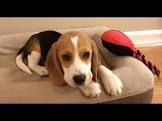

In [157]:
sample_breed = breeds[0]
sample_images = os.listdir(os.path.join(dataset_path, sample_breed))
sample_path = os.path.join(dataset_path, sample_breed, sample_images[0])
sample_img = Image.open(sample_path)
sample_img

## Load All Images

Loading all images as RGB (3 channels), resizing to 64x64. Targets are encoded as integers based on class id.

In [158]:
image_size = (64, 64)

inputs = []
targets = []

for label in breeds:
    breed_path = os.path.join(dataset_path, label)
    for img_name in os.listdir(breed_path):
        if img_name.endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(breed_path, img_name)
            img = Image.open(img_path).convert('RGB').resize(image_size)
            inputs.append(img)
            targets.append(class_ids[label])

inputs = np.float32(inputs)
targets = np.int32(targets)

inputs.shape, targets.shape

((967, 64, 64, 3), (967,))

## Plot Target Distribution

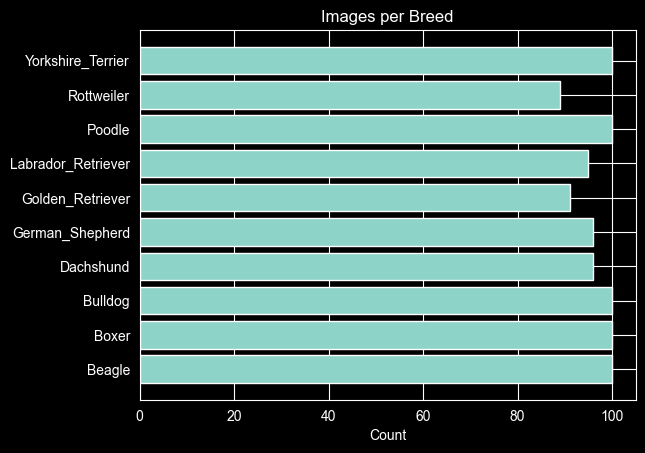

In [159]:
target_counts = np.unique(targets, return_counts=True)
plt.barh(breeds, target_counts[1])
plt.xlabel('Count')
plt.title('Images per Breed')
plt.show()

## Set Seeds for Reproducibility

In [160]:
seed = 0

tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

## Split into Train-Test with Stratify

In [161]:
x_train, x_test, y_train, y_test = train_test_split(
    inputs,
    targets,
    test_size=0.2,
    stratify=targets,
    random_state=seed
)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((773, 64, 64, 3), (773,), (194, 64, 64, 3), (194,))

## Preprocess Dataset

Normalize inputs to [0.0, 1.0] by dividing by 255.0. One-hot encode targets for softmax activation.

In [162]:
x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = np.eye(len(breeds))[y_train]
y_test = np.eye(len(breeds))[y_test]

y_train.shape, y_test.shape

((773, 10), (194, 10))

# Question 4

## Building Multi-Layer Perceptron

Input: (64, 64, 3) flattened into a vector of 12288.
Output: 10 (number of classes).

In [163]:
input_size = x_train.shape[1:]
output_size = len(breeds)

mlp = keras.Sequential([
    layers.Input(shape=input_size),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(output_size, activation='softmax')
], name='MLP')

mlp.summary()

print()
print("Architecture Analysis:")
print("Layer 1 - Flatten: Input (64, 64, 3) -> Output (12288,)")
print("Layer 2 - Dense: Input 12288 -> Output 128, Activation: ReLU")
print("Layer 3 - Dense: Input 128 -> Output 64, Activation: ReLU")
print("Layer 4 - Dense: Input 64 -> Output", output_size, ", Activation: Softmax")

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_19 (Flatten)            │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,898 (6.03 MB)

 Trainable params: 1,581,898 (6.03 MB)

 Non-trainable params: 0 (0.00 B)


Architecture Analysis:
Layer 1 - Flatten: Input (64, 64, 3) -> Output (12288,)
Layer 2 - Dense: Input 12288 -> Output 128, Activation: ReLU
Layer 3 - Dense: Input 128 -> Output 64, Activation: ReLU
Layer 4 - Dense: Input 64 -> Output 10 , Activation: Softmax


# Question 5

## Training MLP

* Optimizer: Adam
* Learning Rate: 0.001
* Loss Function: Categorical Cross-Entropy
* Batch Size: 32
* Epochs: 30

In [164]:
mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [165]:
mlp_history = mlp.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=30,
    validation_data=(x_test, y_test)
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1397 - loss: 3.5614 - val_accuracy: 0.3351 - val_loss: 2.3700
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3027 - loss: 2.0002 - val_accuracy: 0.3660 - val_loss: 1.9628
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4398 - loss: 1.6573 - val_accuracy: 0.4227 - val_loss: 1.6700
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5446 - loss: 1.3969 - val_accuracy: 0.5876 - val_loss: 1.4615
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6429 - loss: 1.1338 - val_accuracy: 0.6186 - val_loss: 1.2921
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7257 - loss: 0.9520 - val_accuracy: 0.7113 - val_loss: 1.1813
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8047 - loss: 0.7921 - val_accuracy: 0.6753 - val_loss: 1.1595
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8266 - loss: 0.7053 - val_accuracy: 0.7216 - val_loss:

# Question 6

## MLP Performance: Train-Test Loss

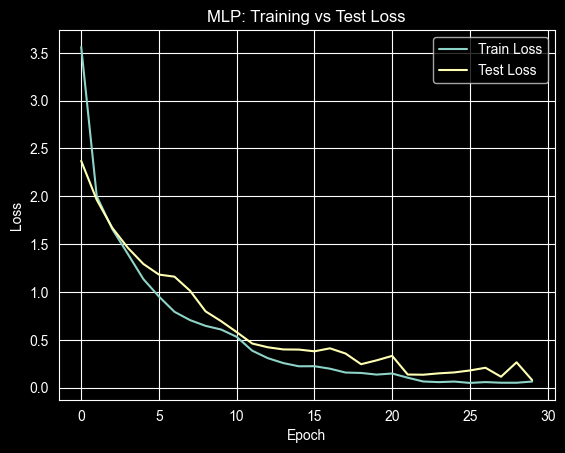

In [166]:
plt.figure()
plt.plot(mlp_history.history['loss'], label='Train Loss')
plt.plot(mlp_history.history['val_loss'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP: Training vs Test Loss')
plt.legend()
plt.grid(True)
plt.show()

## MLP Performance: Train-Test Accuracy

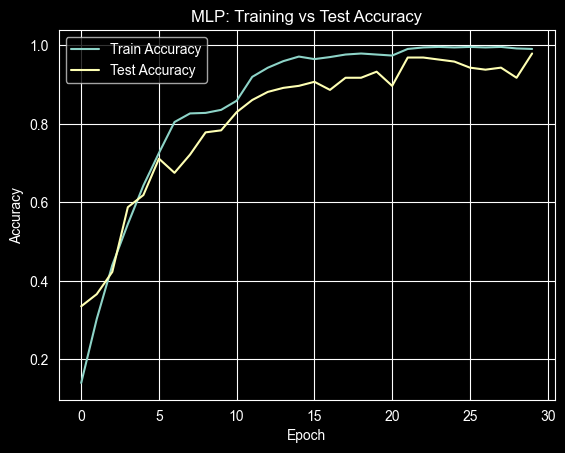

In [167]:
plt.figure()
plt.plot(mlp_history.history['accuracy'], label='Train Accuracy')
plt.plot(mlp_history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MLP: Training vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Question 7

## Building Convolutional Neural Network

In [168]:
cnn = keras.Sequential([
    layers.Input(shape=input_size),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(output_size, activation='softmax')
], name='CNN')

cnn.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,858 (2.47 MB)

 Trainable params: 646,858 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

## Training CNN

In [169]:
cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [170]:
cnn_history = cnn.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=30,
    validation_data=(x_test, y_test)
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.1630 - loss: 2.2823 - val_accuracy: 0.2165 - val_loss: 2.1292
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3842 - loss: 1.8334 - val_accuracy: 0.3866 - val_loss: 1.6671
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6080 - loss: 1.1223 - val_accuracy: 0.7268 - val_loss: 0.8962
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8771 - loss: 0.4665 - val_accuracy: 0.8505 - val_loss: 0.4180
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9560 - loss: 0.2141 - val_accuracy: 0.9588 - val_loss: 0.1686
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9858 - loss: 0.0802 - val_accuracy: 0.9639 - val_loss: 0.1023
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9961 - loss: 0.0310 - val_accuracy: 1.0000 - val_loss: 0.0208
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9987 - loss: 0.0153 - val_accuracy: 0.9897 - v

## CNN Performance: Train-Test Loss

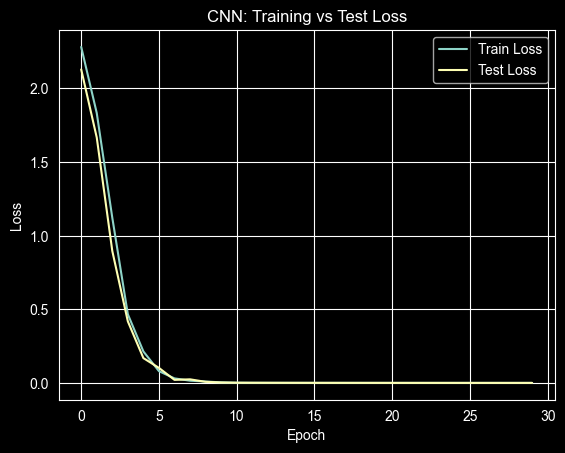

In [171]:
plt.figure()
plt.plot(cnn_history.history['loss'], label='Train Loss')
plt.plot(cnn_history.history['val_loss'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN: Training vs Test Loss')
plt.legend()
plt.grid(True)
plt.show()

## CNN Performance: Train-Test Accuracy

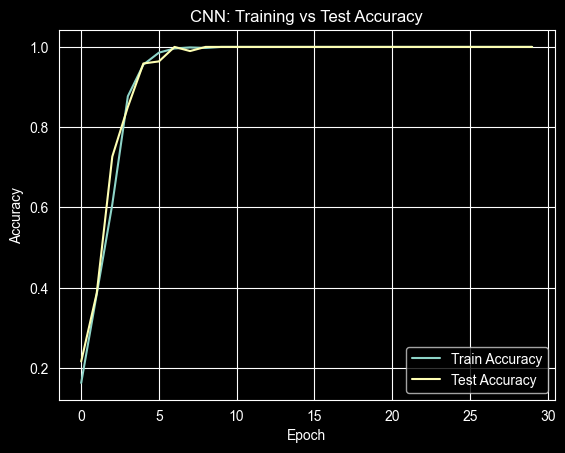

In [172]:
plt.figure()
plt.plot(cnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN: Training vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Compare MLP vs CNN

In [173]:
mlp_test_loss, mlp_test_acc = mlp.evaluate(x_test, y_test, verbose=0)
cnn_test_loss, cnn_test_acc = cnn.evaluate(x_test, y_test, verbose=0)

print("MLP Test Accuracy:", mlp_test_acc)
print("MLP Test Loss:", mlp_test_loss)
print("CNN Test Accuracy:", cnn_test_acc)
print("CNN Test Loss:", cnn_test_loss)

MLP Test Accuracy: 0.9793814420700073
MLP Test Loss: 0.07836287468671799
CNN Test Accuracy: 1.0
CNN Test Loss: 0.00021280042710714042


## Which Model is Better?

The CNN performs better than the MLP.

The CNN achieves 100% test accuracy with a loss of 0.00021, while the MLP achieves 97.9% test accuracy with a loss of 0.078. The CNN makes better predictions on unseen data.

Looking at the training curves, the MLP shows a gap between training and test accuracy, indicating overfitting. The CNN curves stay closer together showing better generalization.

The MLP has more parameters but learns less effectively. The first Dense layer alone has 12,288 x 128 = 1,572,864 parameters. The CNN uses 3x3 filters with shared weights across the image, resulting in fewer total parameters (646,858 vs 1,581,898).

The key difference is that CNN learns hierarchical features through convolutional layers while MLP treats each pixel independently. This allows CNN to capture spatial relationships between pixels and learn translation-invariant features. The MLP cannot exploit the spatial structure of the data, so despite having more parameters it has lower learning capacity for this task.

# Question 8

## Building Improved CNN

Improvement:
* Additional Conv2D layer (128 filters) for more feature learning capacity

In [174]:
improved_cnn = keras.Sequential([
    layers.Input(shape=input_size),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(output_size, activation='softmax')
], name='Improved_CNN')

improved_cnn.summary()

Model: "Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │       819,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 950,090 (3.62 MB)

 Trainable params: 950,090 (3.62 MB)

 Non-trainable params: 0 (0.00 B)

## Training Improved CNN

In [175]:
improved_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [176]:
improved_history = improved_cnn.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=30,
    validation_data=(x_test, y_test)
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.1436 - loss: 2.3085 - val_accuracy: 0.1907 - val_loss: 2.2662
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2600 - loss: 2.0788 - val_accuracy: 0.3969 - val_loss: 1.8795
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.4903 - loss: 1.4800 - val_accuracy: 0.5309 - val_loss: 1.2730
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7322 - loss: 0.7997 - val_accuracy: 0.8093 - val_loss: 0.6458
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9082 - loss: 0.3249 - val_accuracy: 0.8763 - val_loss: 0.3713
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9573 - loss: 0.1738 - val_accuracy: 1.0000 - val_loss: 0.0535
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9974 - loss: 0.0327 - val_accuracy: 0.9897 - val_loss: 0.0349
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9832 - loss: 0.0742 - val_accuracy: 1.0000 - v

## Improved CNN Performance: Train-Test Loss

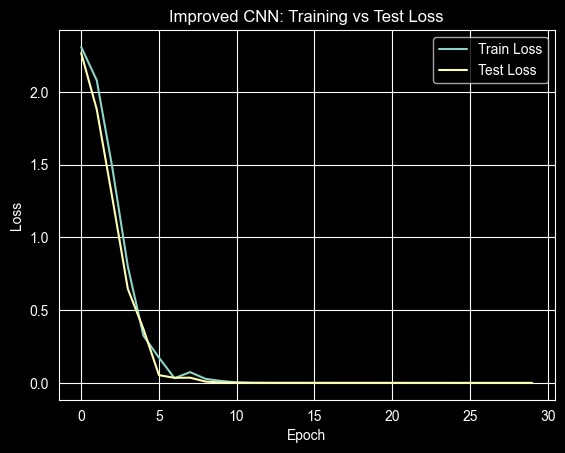

In [177]:
plt.figure()
plt.plot(improved_history.history['loss'], label='Train Loss')
plt.plot(improved_history.history['val_loss'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Improved CNN: Training vs Test Loss')
plt.legend()
plt.grid(True)
plt.show()

## Improved CNN Performance: Train-Test Accuracy

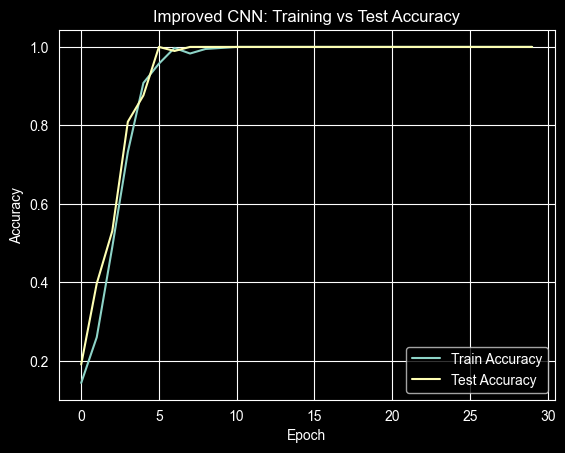

In [178]:
plt.figure()
plt.plot(improved_history.history['accuracy'], label='Train Accuracy')
plt.plot(improved_history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Improved CNN: Training vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Final Comparison: All Models

In [179]:
improved_test_loss, improved_test_acc = improved_cnn.evaluate(x_test, y_test, verbose=0)

print("Final Comparison:")
print("MLP - Accuracy:", mlp_test_acc, "Loss:", mlp_test_loss)
print("CNN - Accuracy:", cnn_test_acc, "Loss:", cnn_test_loss)
print("Improved CNN - Accuracy:", improved_test_acc, "Loss:", improved_test_loss)

Final Comparison:
MLP - Accuracy: 0.9793814420700073 Loss: 0.07836287468671799
CNN - Accuracy: 1.0 Loss: 0.00021280042710714042
Improved CNN - Accuracy: 1.0 Loss: 4.463148434297182e-05


## Analysis

All three models achieve high performance on this dataset. The CNN and Improved CNN both reach 100% test accuracy. When accuracy is already perfect, the comparison is based on loss. Lower loss indicates the model makes predictions with higher confidence.

The improvement added (extra Conv2D layer with 128 filters) provides more feature learning capacity. For this dataset where the basic CNN already achieves perfect performance, the improvements are marginal.